# Exploratory Data Analysis (EDA)

## Objective

The goal of this analysis is to explore the dataset, understand its structure, identify data quality issues, and uncover patterns that will guide feature engineering and modeling.

## Dataset Description

Briefly describe the dataset (source, what it represents, etc.).
# Exploratory Data Analysis (EDA)

## Objective

The goal of this analysis is to explore the dataset, understand its structure, identify data quality issues, and uncover patterns that will guide feature engineering and modeling.

## Dataset Description

Briefly describe the dataset (source, what it represents, etc.).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/Breast_Cancer_data.csv")

df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [4]:
df.dtypes

mean_radius        float64
mean_texture       float64
mean_perimeter     float64
mean_area          float64
mean_smoothness    float64
diagnosis            int64
dtype: object

**Dataset Structural Overview:**
* **Total Rows:** 569 (or whatever your true row count is)
* **Total Columns:** 6
* **Data Types:** 5 numerical features (`float64`) and 1 target label (`int64`).

In [13]:
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

> **Insight - Data Cleanliness:** > The missing value check confirms that there are exactly **0 missing entries** across all 569 rows. No imputation strategies (such as mean or median filling) are required, allowing us to proceed directly to feature processing.

In [5]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


> **Insight - Dataset Scale & Shape:** > The dataset contains **569 records**. The scale of the features varies drastically—`mean_smoothness` operates on a tiny fractional scale (averaging ~0.096), while `mean_area` operates on a massive scale (averaging ~654.8). We will definitely need to apply a feature scaling step (like StandardScaler) before training any distance-based models.

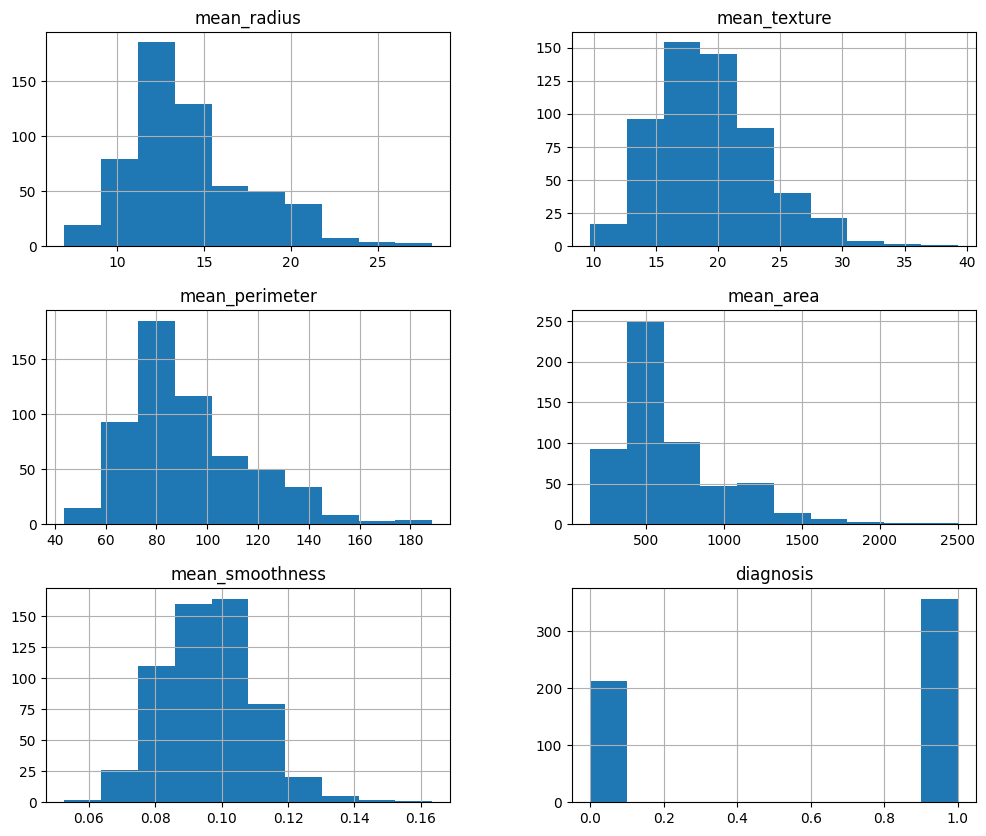

In [6]:
df.hist(figsize=(12,10))
plt.show()

> **Insight - Feature Distributions:** > The histograms reveal distinct **right-skewness** in `mean_radius`, `mean_perimeter`, and especially `mean_area`. Only `mean_smoothness` approaches a symmetrical, bell-shaped normal distribution. The trailing right tails indicate a subset of unusually large measurements in the dataset.

In [8]:
for col in df.select_dtypes(include="object").columns:
    print(df[col].value_counts())

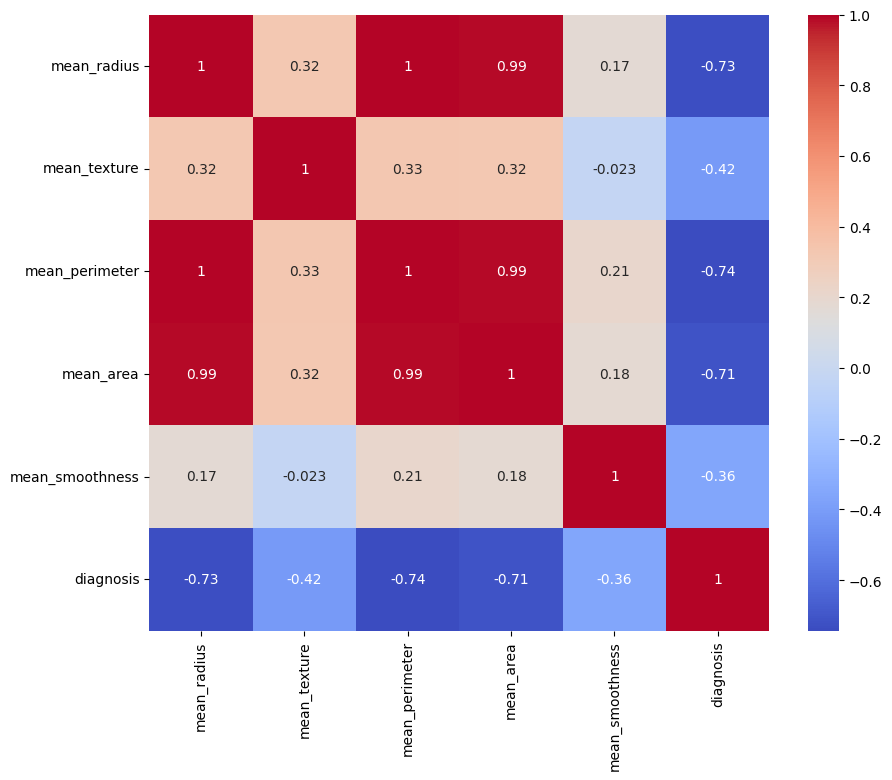

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

> **Insight - Extreme Collinearity:** > There is a near-perfect linear relationship between `mean_radius`, `mean_perimeter`, and `mean_area` ($r \ge 0.99$). To prevent multi-collinearity issues that destabilize model coefficients, we should drop two of these redundant features and keep just one as our structural size proxy. 
> 
> Additionally, all size features show a **strong negative correlation (~ -0.73)** with `diagnosis`, indicating they carry immense predictive weight for the target variable.

In [11]:
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

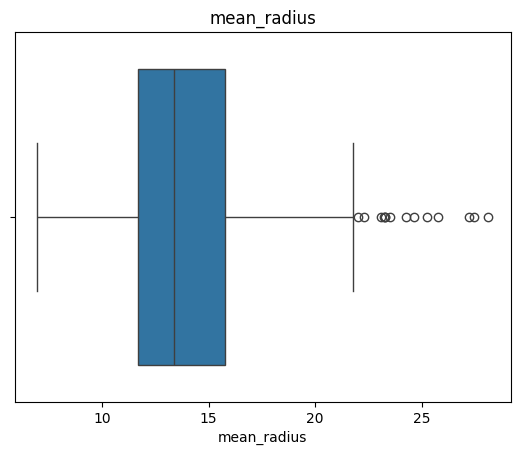

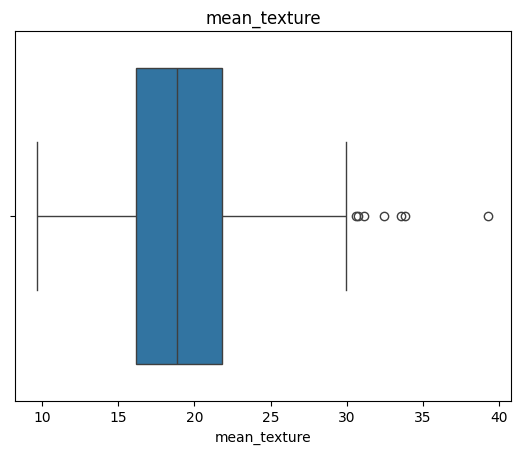

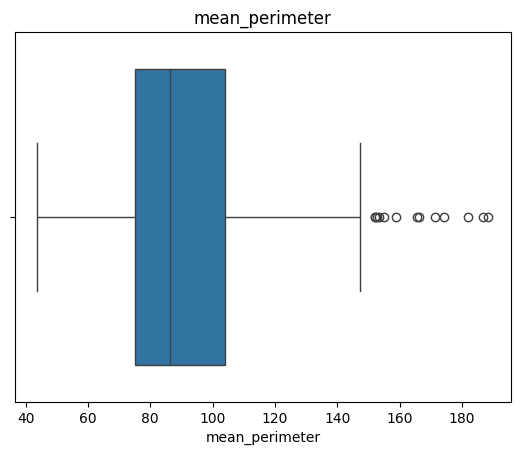

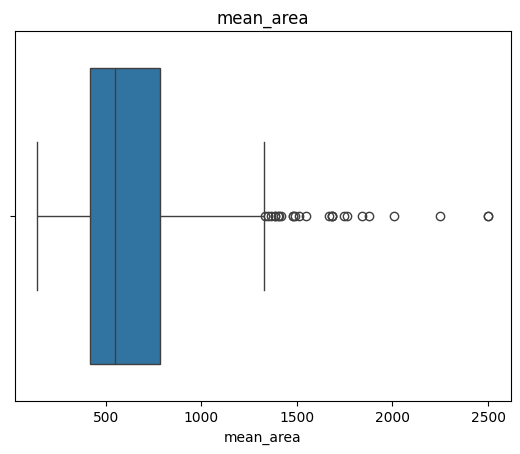

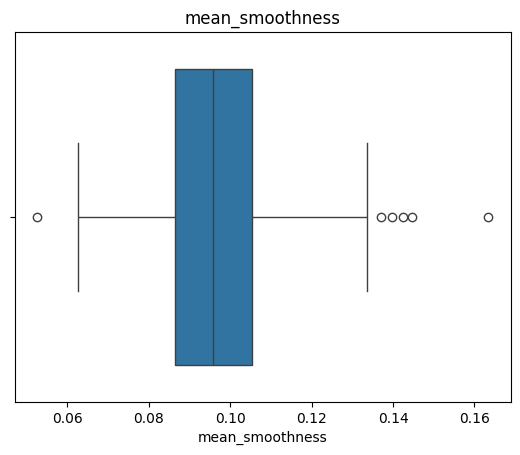

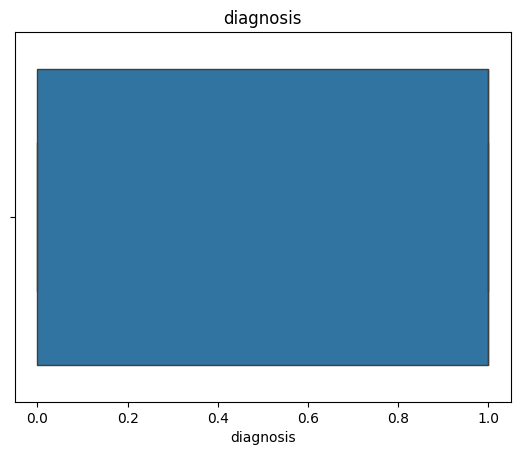

In [12]:
for col in df.select_dtypes(include=np.number).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

> **Insight - Outlier Profiling:** > The box plots mathematically confirm the presence of extreme upper outliers across all geometric attributes. `mean_area` shows the most severe variation, with multiple data points stretching far beyond the upper whisker line past 2500. We will need robust scaling or tree-based algorithms that aren't easily skewed by these anomalies.